# Monte Carlo: global parameters vs. TRGB error

The parameters of the data, not of the method: `N_1mag`, the AGB-to-RGB ratio `R` and
`photometric_error`. A **scenario** says what to do with each of them — hold it at a value, or draw it
from a range for every realization — and every scenario is drawn on the plots in its own colour. Which
parameter is studied is therefore a matter of editing `scenarios`, nothing else, and drawing two of
them at once is how the two-dimensional cases of the plan are run.

Every scenario is given the same realizations, and a parameter drawn from the same range in two
scenarios takes the same value in both, so the comparison between scenarios is paired the way the `d`
values are paired in `d_param_mc.ipynb`.

This is point 1 of the plan in `README.md`. The question is not whether a larger sample is measured
better — it must be — but whether the **quality to error relation** moves when a global parameter
moves, or whether every scenario falls on the same curve.

Detections the method could not deliver are counted per scenario, not recorded as rows: they are the
low-quality, large-error cases, so dropping them makes the weak end of any curve read better than it
is.

In [19]:
# source ../.venv/bin/activate

# trzeba uruchomic jupyter lab z tego juz dzialajacego srodowiska

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import math

from tqdm.auto import tqdm

from trgb_lib import *

print("ok")

ok


In [21]:
# ============================================================
# Simulation parameters held fixed in every scenario
# ============================================================

m_trgb = 10.0

alpha_rgb = 0.30
rgb_range = 3.0

alpha_agb = 0.20
agb_range = 2.0

In [36]:
# Size of the run, and what each scenario does with the simulation parameters.

N_realizations = 100000

# One entry per curve on the plots. Within a scenario each parameter is either
#
#     a number     held at that value,
#     [lo, hi]     drawn uniformly in that range, once per realization.
#
# R = N_agb_1mag / N_rgb_1mag. A drawn N_1mag is uniform in the star count itself, not in its
# logarithm. Every scenario must list all three parameters.

parameter_names = ("N_1mag", "R", "photometric_error")

scenarios = [
    {"N_1mag": 200, "R": 0.2, "photometric_error": [0.005,0.3]},
    {"N_1mag": 1000, "R": 0.2, "photometric_error": [0.005,0.3]},
]

# Detection settings, identical in every scenario — this notebook is about the data, not the method.

d = 0.20
step = 0.01
sigma = 0.01

In [37]:
def draw_parameter(spec, seed):
    """
    Turn one scenario entry into the value it takes in a single realization.

    Parameters
    ----------
    spec : float or sequence of two floats
        A number is held as it is. A two-element [lo, hi] is drawn uniformly from that range.
    seed : int
        Random seed. The value comes from one uniform variate, so the same seed and the same
        range give the same value — that is what keeps the scenarios paired.

    Returns
    -------
    float
        Value of the parameter for this realization.
    """

    if isinstance(spec, (list, tuple, np.ndarray)):

        if len(spec) != 2:
            raise ValueError("A drawn parameter must be given as [lo, hi].")

        lo, hi = float(spec[0]), float(spec[1])

        if not hi > lo:
            raise ValueError("A drawn parameter needs hi > lo.")

        return float(np.random.default_rng(seed).uniform(lo, hi))

    return float(spec)


def scenario_label(scenario):
    """Legend text for one scenario: every parameter with its value or its range."""

    return ", ".join(f"{name} = {scenario[name]}" for name in parameter_names)


# A missing or misspelled parameter would silently fall back to nothing, so check the scenarios
# before spending the run on them.

for scenario in scenarios:

    if set(scenario) != set(parameter_names):
        raise ValueError(f"Every scenario must list exactly {parameter_names}, got {tuple(scenario)}.")

for scenario in scenarios:
    print(scenario_label(scenario))

N_1mag = 200, R = 0.2, photometric_error = [0.005, 0.3]
N_1mag = 1000, R = 0.2, photometric_error = [0.005, 0.3]


In [40]:
# ============================================================
# Independent random-number streams
# ============================================================

master_seed = random_seed()

master_sequence = np.random.SeedSequence(master_seed)
realization_sequences = master_sequence.spawn(N_realizations)

# ============================================================
# Monte Carlo simulation
# ============================================================

results = []

n_failed = {i: 0 for i in range(len(scenarios))}
n_failed_alpha = {i: 0 for i in range(len(scenarios))}

for realization, realization_sequence in enumerate(tqdm(realization_sequences, desc="Monte Carlo")):

    # One stream per parameter, so that a parameter drawn from the same range in two scenarios
    # lands on the same value in both, then streams for RGB, AGB and photometric noise.
    parameter_sequences = realization_sequence.spawn(len(parameter_names))
    rgb_sequence, agb_sequence, phot_sequence = (realization_sequence.spawn(3))

    parameter_seeds = {name: int(sequence.generate_state(1, dtype=np.uint32)[0]) for name, sequence in zip(parameter_names, parameter_sequences)}

    seed_rgb = int(rgb_sequence.generate_state(1, dtype=np.uint32)[0])
    seed_agb = int(agb_sequence.generate_state(1, dtype=np.uint32)[0])
    seed_phot = int(phot_sequence.generate_state(1, dtype=np.uint32)[0])

    # --------------------------------------------------------
    # The same realization run through every scenario
    # --------------------------------------------------------

    for i_scenario, scenario in enumerate(scenarios):

        parameters = {name: draw_parameter(scenario[name], parameter_seeds[name]) for name in parameter_names}

        N_1mag = round(parameters["N_1mag"])   # a star count, so the only one that has to be an integer
        R = parameters["R"]
        photometric_error = parameters["photometric_error"]

        N_agb_1mag = round(R * N_1mag)

        # The seeds are reused across scenarios, so at equal N_1mag the RGB sample is literally the
        # same star list and the photometric noise is the same deviates rescaled by the error.

        m_rgb = rgb_lf(m_trgb=m_trgb,alpha=alpha_rgb,m_range=rgb_range,N_1mag=N_1mag,seed=seed_rgb,)
        m_agb = agb_powerlaw_lf(m_trgb=m_trgb,alpha=alpha_agb,m_range=agb_range,N_agb_1mag=N_agb_1mag,seed=seed_agb,)
        m = np.concatenate((m_rgb,m_agb,))
        m = add_photometric_errors(m,errors=photometric_error,seed=seed_phot,)
        m = np.sort(m)

        # --------------------------------------------------------
        # RGB slope: the catalogue differs between scenarios, so unlike in d_param_mc.ipynb this is
        # fitted inside the scenario loop. A scenario that loses the fit drops that row only.
        # --------------------------------------------------------

        try:

            alpha_mle, alpha_err, res = fit_alpha_mle(m,m1=m_trgb + 0.5,m2=m_trgb + 2.0,)

        except (
            ValueError,
            RuntimeError,
            IndexError,
            ZeroDivisionError,
        ):

            n_failed_alpha[i_scenario] += 1
            continue

        # --------------------------------------------------------
        # Detection
        # --------------------------------------------------------

        try:

            x_filter, response, counts_bright, counts_faint = local_poisson_filter(m,d=d,alpha=alpha_mle,step=step,sigma=sigma,method="score",)
            trgb_detected, diagnostics = detect_local_peak(x_filter,response,d=d,initial=m_trgb,search_range=0.5,competitor_fraction=0.5)

            trgb_error = trgb_detected - m_trgb


            scale = np.sqrt(0.1)/np.sqrt(d)   # constant here, kept so the numbers compare with d_param_mc.ipynb
            results.append({
                "realization": realization,
                "scenario": i_scenario,

                "N_1mag": N_1mag,
                "N_agb_1mag": N_agb_1mag,
                "N_stars": len(m),
                "R": R,
                "photometric_error": photometric_error,

                "seed_rgb": seed_rgb,
                "seed_agb": seed_agb,
                "seed_phot": seed_phot,

                "alpha_mle": alpha_mle,

                "trgb_true": m_trgb,
                "trgb_detected": trgb_detected,
                "trgb_error": trgb_error,
                "absolute_error": abs(trgb_error),

                "peak_height":diagnostics["peak_height"],
                "peak_height_scale":diagnostics["peak_height"]*scale,
                "peak_prominence":diagnostics["peak_prominence"],
                "peak_width":diagnostics["peak_width_half"],
                "peak_flatness":diagnostics["peak_flatness"],
                "sharpness":diagnostics["sharpness"],
                "area_main":diagnostics["area_main"],
                "area_outside_bright":diagnostics["area_outside_bright"],
                "area_outside_faint":diagnostics["area_outside_faint"],
                "area_outside":diagnostics["area_outside"],
                "outside_area_fraction":diagnostics["outside_area_fraction"],
            })

        except (
            ValueError,
            RuntimeError,
            IndexError,
            ZeroDivisionError,
        ):

            n_failed[i_scenario] += 1


# Failures are not spread evenly over the scenarios, and dropping them is a selection: a scenario
# that fails often is left with only the realizations that happened to go well. Hence the breakdown.

print(f"realizations: {N_realizations}, scenarios: {len(scenarios)}")

print(f"detections: {len(results)} succeeded, {sum(n_failed.values()) + sum(n_failed_alpha.values())} failed")

for i, scenario in enumerate(scenarios):
    print(f"    scenario {i}: {n_failed_alpha[i]:5d} lost at the slope fit, {n_failed[i]:5d} lost in detection    {scenario_label(scenario)}")

Monte Carlo:   0%|          | 0/100000 [00:00<?, ?it/s]

realizations: 100000, scenarios: 2
detections: 200000 succeeded, 0 failed
    scenario 0:     0 lost at the slope fit,     0 lost in detection    N_1mag = 200, R = 0.2, photometric_error = [0.005, 0.3]
    scenario 1:     0 lost at the slope fit,     0 lost in detection    N_1mag = 1000, R = 0.2, photometric_error = [0.005, 0.3]


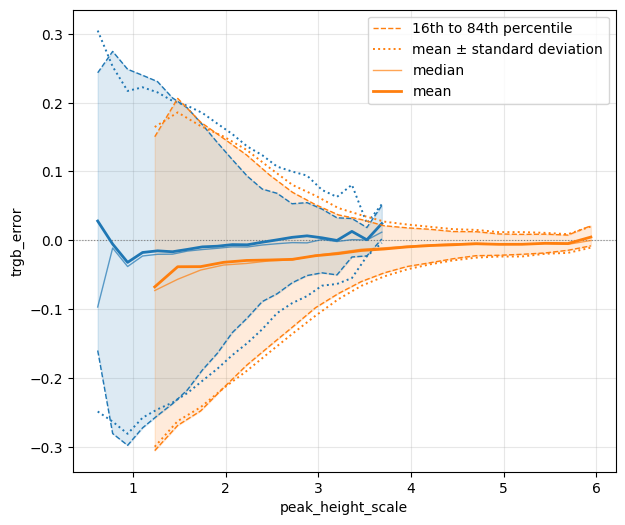

In [45]:
# What goes on the axes. Swap these to plot any other pair of recorded columns —
# everything below works on x and y only.

#x_key = "N_1mag"
#x_key = "photometric_error"
x_key = "peak_height_scale"



y_key = "trgb_error"
#y_key = "absolute_error"
#y_key = "peak_height_scale"


x_label = x_key
y_label = y_key


# Trend of y along x: the range of x is split into equal-width bins, and every bin is described
# twice over — by the median with a percentile interval, and by the mean with the standard
# deviation. The two answer different questions. A percentile interval says where the bulk of the
# detections sit and does not care how far the worst ones went; the standard deviation feels every
# outlier. So the gap between the dotted envelope and the dashed one measures the catastrophic
# tail, and the gap between mean and median says which side that tail is on.
#
# Bins holding fewer points than min_count are left empty instead of pretending to be a measurement.

n_bins = 20
min_count = 3

percentile_low = 16
percentile_high = 84


plt.figure(figsize=(7,6))

for i, scenario in enumerate(scenarios):

    color = f"C{i}"

    x = np.array([r[x_key] for r in results if r["scenario"] == i])
    y = np.array([r[y_key] for r in results if r["scenario"] == i])

    #plt.scatter(x, y, s=10, alpha=0.05, color=color, zorder=1, label=scenario_label(scenario))


    # ---------- Where y sits and how far it spreads, per bin of x ----------

    edges = np.linspace(x.min(), x.max(), n_bins + 1)

    centers = 0.5 * (edges[:-1] + edges[1:])

    means = np.full(n_bins, np.nan)
    scatters = np.full(n_bins, np.nan)
    medians = np.full(n_bins, np.nan)
    lows = np.full(n_bins, np.nan)
    highs = np.full(n_bins, np.nan)

    for j in range(n_bins):

        # The last bin keeps its right edge, so that the highest point is counted too.
        if j == n_bins - 1:
            in_bin = (x >= edges[j]) & (x <= edges[j + 1])
        else:
            in_bin = (x >= edges[j]) & (x < edges[j + 1])

        if in_bin.sum() >= min_count:
            means[j] = np.mean(y[in_bin])
            scatters[j] = np.std(y[in_bin], ddof=1)
            medians[j] = np.median(y[in_bin])
            lows[j] = np.percentile(y[in_bin], percentile_low)
            highs[j] = np.percentile(y[in_bin], percentile_high)


    # ---------- Mark them on the plot ----------

    # The colour ties every line to its own scatter, so the scenario is named once and the styles
    # are described once — on the last scenario, which puts the scenarios together at the top of the
    # legend and the style key under them. zorder keeps the envelopes above every scatter, otherwise
    # the last scenario plotted would bury the bands of the earlier ones.

    described = i == len(scenarios) - 1

    plt.fill_between(centers, lows, highs, color=color, alpha=0.15, zorder=2)

    plt.plot(centers, lows, "--", color=color, linewidth=1, zorder=3, label=f"{percentile_low}th to {percentile_high}th percentile" if described else None)
    plt.plot(centers, highs, "--", color=color, linewidth=1, zorder=3)

    plt.plot(centers, means - scatters, ":", color=color, linewidth=1.4, zorder=3, label="mean ± standard deviation" if described else None)
    plt.plot(centers, means + scatters, ":", color=color, linewidth=1.4, zorder=3)

    plt.plot(centers, medians, "-", color=color, linewidth=1, alpha=0.7, zorder=3, label="median" if described else None)
    plt.plot(centers, means, "-", color=color, linewidth=2, zorder=3, label="mean" if described else None)


plt.axhline(0.0, color="gray", linestyle=":", linewidth=0.8)

plt.xlabel(x_label)
plt.ylabel(y_label)

plt.grid(alpha=0.3)
plt.legend()

plt.show()